In [10]:
import sys
from pathlib import Path
import os
sys.path.append(str(Path.cwd().parent))

from src.modeling import ModelBenchmark, get_feature_importance, get_coefficients, plot_learning_curves_trained_models
import joblib

import importlib
if 'src.data_processing' in sys.modules:
    import src.data_processing
    importlib.reload(src.data_processing)
if 'src.modeling' in sys.modules:
    import src.modeling
    importlib.reload(src.modeling)
from src.modeling import ModelBenchmark, get_feature_importance, get_coefficients
from src.data_processing import load_processed_data
import matplotlib.pyplot as plt



In [2]:
df = load_processed_data(r"data\processed\features_data_encoded.csv")

Wczytywanie danych z: C:\Users\aiszk\PycharmProjects\PythonProject\data\processed\features_data_encoded.csv
✓ Wczytano 3,931,227 wierszy, 72 kolumn


In [3]:
# Drop non-features columns
drop_cols = ['timestamp', 'meter_id', 'campus_id', 'consumption', 'date_dt', 'id', 'id_building', 'id_campus']
drop_cols = [col for col in drop_cols if col in df.columns]

X = df.drop(drop_cols, axis=1)
y = df['consumption']

# Usuń kolumny kategoryczne (strings)
categorical_cols = X.select_dtypes(include=['object']).columns
print(f"Kolumny kategoryczne: {list(categorical_cols)}")

X = X.drop(categorical_cols, axis=1)

# Sprawdzenie czy nie ma NaN
print(f"Braki danych: {X.isnull().sum().sum()}")
if X.isnull().sum().sum() > 0:
    X = X.fillna(X.mean())
    print("✓ Braki uzupełnione średnią")

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Typ danych X:\n{X.dtypes}")

# Split train/test (80/20 temporal)
split_idx = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Train: {X_train.shape}")
print(f"Test:  {X_test.shape}")

Kolumny kategoryczne: []
Braki danych: 0
X shape: (3931227, 70)
y shape: (3931227,)
Typ danych X:
gross_floor_area        float64
room_area               float64
capacity                float64
capacity_campus           int64
apparent_temperature    float64
                         ...   
built_year_1993.0         int64
built_year_1999.0         int64
built_year_2013.0         int64
built_year_2014.0         int64
built_year_2019.0         int64
Length: 70, dtype: object
Train: (3144981, 70)
Test:  (786246, 70)


In [4]:
# Trening modeli
benchmark = ModelBenchmark()
results = benchmark.train_and_evaluate(X_train, X_test, y_train, y_test)


TRENING MODELI
None bez skalowania
Skalowanie danych dla modelu: Lasso
  Train RMSE: 2.5316 | Test RMSE: 2.2309
  Train MAE:  1.5176 | Test MAE:  1.4435
  Train R²:   0.9832 | Test R²:   0.9375
Skalowanie danych dla modelu: Ridge
  Train RMSE: 1.6400 | Test RMSE: 821.6642
  Train MAE:  0.8832 | Test MAE:  627.7446
  Train R²:   0.9930 | Test R²:   -8470.6568
Skalowanie danych dla modelu: ElasticNet
  Train RMSE: 2.9545 | Test RMSE: 3.2394
  Train MAE:  1.8538 | Test MAE:  2.4231
  Train R²:   0.9771 | Test R²:   0.8683
RandomForest bez skalowania
  Train RMSE: 0.5449 | Test RMSE: 3.8611
  Train MAE:  0.2218 | Test MAE:  2.5111
  Train R²:   0.9992 | Test R²:   0.8129
GradientBoosting bez skalowania
  Train RMSE: 1.1499 | Test RMSE: 2.2866
  Train MAE:  0.6853 | Test MAE:  1.4673
  Train R²:   0.9965 | Test R²:   0.9344


In [7]:
# Podsumowanie wyników
print("\n" + "="*80)
print("PODSUMOWANIE WYNIKÓW")
print("="*80)

results_df = benchmark.get_results_df()
print(results_df)


PODSUMOWANIE WYNIKÓW
                  train_rmse   test_rmse  train_mae    test_mae  train_r2  \
Lasso               2.531640    2.230902   1.517587    1.443528  0.983209   
GradientBoosting    1.149930    2.286616   0.685258    1.467290  0.996536   
ElasticNet          2.954516    3.239373   1.853784    2.423071  0.977132   
RandomForest        0.544877    3.861125   0.221751    2.511146  0.999222   
Ridge               1.639958  821.664204   0.883202  627.744557  0.992954   

                      test_r2  
Lasso                0.937549  
GradientBoosting     0.934391  
ElasticNet           0.868326  
RandomForest         0.812929  
Ridge            -8470.656774  


In [8]:
# Najlepszy model
best_name, best_model = benchmark.get_best_model()
print(f"\n✓ Najlepszy model: {best_name}")
print(f"  Test RMSE: {benchmark.results[best_name]['test_rmse']:.4f}")



✓ Najlepszy model: Lasso
  Test RMSE: 2.2309


In [11]:
# Wydobądź i zapisz Lasso
lasso_benchmark = benchmark.trained_models['Lasso']
joblib.dump(lasso_benchmark, '../models/lasso_benchmark.joblib')

# Wydobądź i zapisz GB
gb_benchmark = benchmark.trained_models['GradientBoosting']
joblib.dump(gb_benchmark, '../models/gb_benchmark.joblib')

print("✓ Saved to:", os.path.abspath('../models/lasso_benchmark.joblib'))
print("✓ Saved to:", os.path.abspath('../models/gb_benchmark.joblib'))

✓ Saved to: C:\Users\aiszk\PycharmProjects\PythonProject\models\lasso_benchmark.joblib
✓ Saved to: C:\Users\aiszk\PycharmProjects\PythonProject\models\gb_benchmark.joblib


In [16]:
# Zapisz X_test i y_test do porównań
joblib.dump(X_test, '../data/processed/X_test_benchmark.joblib')
joblib.dump(y_test, '../data/processed/y_test_benchmark.joblib')
joblib.dump(X_train, '../data/processed/X_train_benchmark.joblib')
joblib.dump(y_train, '../data/processed/y_train_benchmark.joblib')

print("✅ X_test_benchmark saved!")
print(f"Shape: {X_test.shape}")
print("Columns:", X_test.columns.tolist())
print(y_test.shape)

✅ X_test_benchmark saved!
Shape: (786246, 70)
Columns: ['gross_floor_area', 'room_area', 'capacity', 'capacity_campus', 'apparent_temperature', 'dew_point_temperature', 'relative_humidity', 'wind_speed', 'wind_direction', 'is_holiday', 'is_semester', 'is_exam', 'hour', 'day_of_week', 'month', 'day_of_month', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'day_sin', 'day_cos', 'is_weekend', 'is_night', 'is_morning', 'is_afternoon', 'is_evening', 'consumption_lag_168h', 'consumption_rolling_std_3h', 'consumption_rolling_std_6h', 'consumption_rolling_std_24h', 'temperature_diff', 'consumption_per_sqm', 'consumption_per_person', 'decade_1960s', 'decade_1970s', 'decade_1980s', 'decade_1990s', 'decade_2000s', 'decade_2010s', 'day_hour_interaction', 'pca_1', 'pca_2', 'pca_3', 'pca_4', 'pca_5', 'pca_6', 'category_mixed use', 'category_office', 'category_other', 'category_sport', 'category_teaching', 'built_year_1965.0', 'built_year_1966.0', 'built_year_1967.0', 'built_year_1968.0', 'built_y

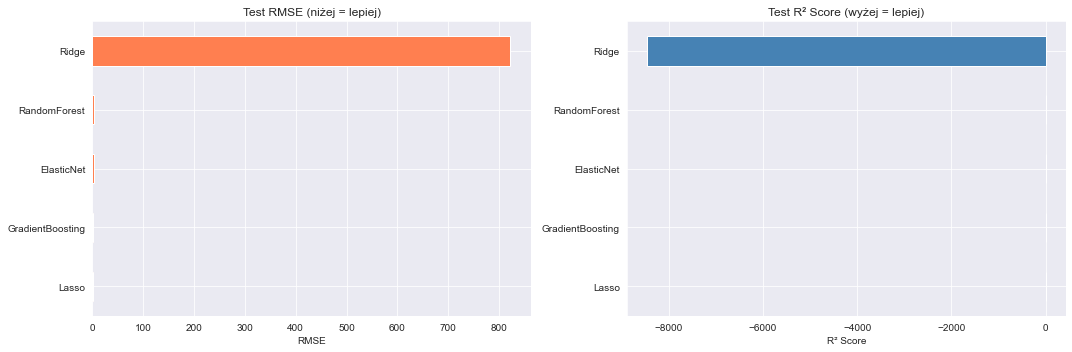

In [12]:
# Wizualizacja wyników
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Test RMSE
results_df['test_rmse'].plot(kind='barh', ax=axes[0], color='coral')
axes[0].set_title('Test RMSE (niżej = lepiej)')
axes[0].set_xlabel('RMSE')

# Test R²
results_df['test_r2'].plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Test R² Score (wyżej = lepiej)')
axes[1].set_xlabel('R² Score')

plt.tight_layout()
plt.show()


###

### Lasso i Gradient Boosting - najlepsze modele jako baseline
Lasso: train_rmse ≈ 2.53, test_rmse ≈ 2.23, train_r2 ≈ 0.983, test_r2 ≈ 0.938.
Model lekko lepszy na train niż na test (normalne), ale różnice są małe – wygląda na stabilny, bez silnego overfittingu.

GradientBoosting: train_rmse ≈ 1.15 (dużo mniejszy niż Lasso), test_rmse ≈ 2.29, train_r2 ≈ 0.997, test_r2 ≈ 0.934.
Tu widać lekki overfitting (train dużo lepszy niż test), ale test_r2 jest podobne do Lasso – można go traktować jako trochę bardziej dopasowany, ale też bardziej ryzykowny przy generalizacji.

ElasticNet
train_rmse ≈ 2.95, test_rmse ≈ 3.24, test_r2 ≈ 0.87.
Jest wyraźnie słabszy na te dane niż Lasso i Gradient Boosting – zarówno RMSE, jak i R² są gorsze na train i test.

Random Forest
train_rmse ≈ 0.54 (prawie perfekcyjne dopasowanie), ale test_rmse ≈ 3.86 i test_r2 ≈ 0.81.
To klasyczny przykład mocnego overfittingu: las idealnie „nauczył się” treningu, ale dużo gorzej radzi sobie na teście. Różnica między train i test jest bardzo duża, więc w obecnej konfiguracji nie jest dobrym modelem produkcyjnym.

Ridge
train_rmse ≈ 1.64 (ok), ale test_rmse ≈ 822 i test_r2 ≈ −8470.
Tak ekstremalnie zły test_r2 oznacza, że model na teście jest dużo gorszy niż przewidywanie samej średniej celu; zwykle wskazuje to na błąd w preprocessing’u (np. inne skalowanie, błąd w target transformacji, pomyłka w jednostkach) albo złą konfigurację modelu.
Ten wynik trzeba traktować jako „model do wyrzucenia / do debugowania”, a nie jako realną alternatywę.

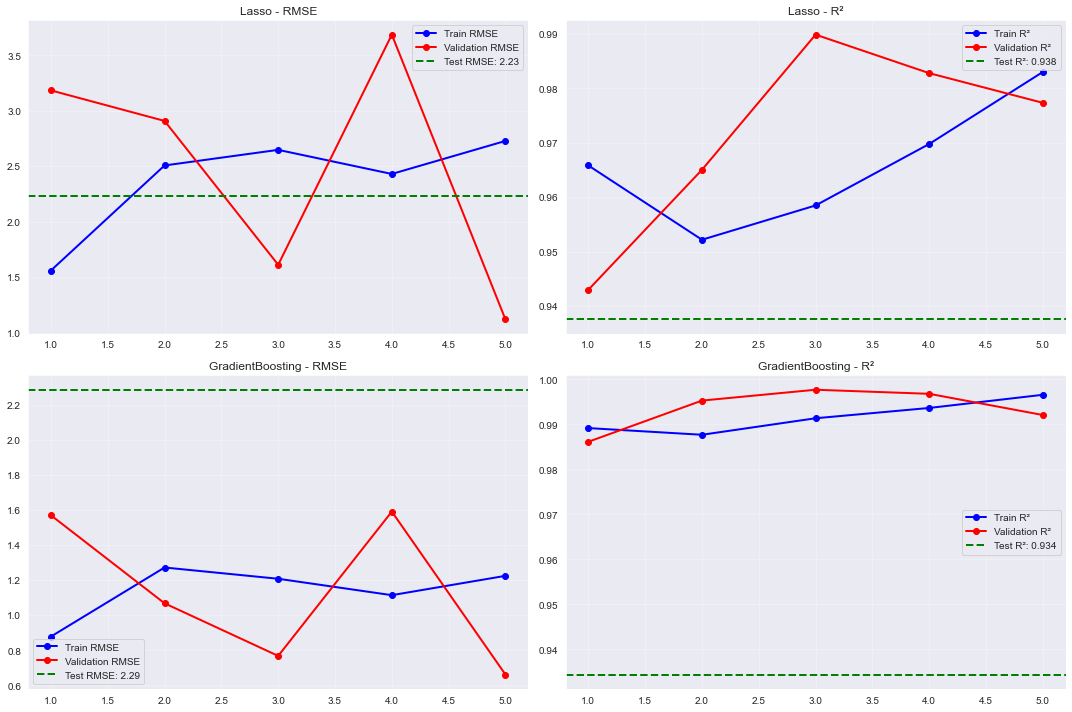

In [13]:
plot_learning_curves_trained_models(benchmark, X_train, y_train, X_test, y_test)

### 1. Lasso
 #### a. RMSE
Train RMSE (niebieski) rośnie z ~1.5 do ~2.8 w kolejnych foldach

Validation RMSE (czerwony) jest bardzo niestabilny: spada z 3.2 do 1.6, skacze do 4.0, wraca do ~1.1

Test RMSE: 2.23 (zielona linia) jest niższy niż większość walidacji — dobry znak stabilności

#### Wniosek: Model Lasso ma wahania w walidacji, ale ostatecznie dobrze generalizuje na teście

#### b. R²
Train R² (niebieski) rośnie od 0.94 do 0.98 — model uczy się coraz lepiej

Validation R² (czerwony) bardzo niestabilny: od 0.04 do 0.99!

Test R²: 0.938 (zielona linia) — świetny wynik, model generalizuje bardzo dobrze

#### Wniosek: Pomimo wahań w walidacji, na teście Lasso osiąga wysoki R²

### 2. GradientBoosting
###  a. RMSE
Train RMSE (niebieski) rośnie z ~0.9 do ~1.25 — niższy niż Lasso (lepsze dopasowanie)

Validation RMSE (czerwony) bardziej stabilny: 1.55 → 1.05 → 0.75 → 1.6 → 0.7

Test RMSE: 2.29 (zielona linia) jest wyższy niż ostatnie foldy walidacji (0.7) — sugeruje lekki overfitting

#### Wniosek: GB ma lepsze dopasowanie na treningu, ale słabiej generalizuje niż Lasso

### b. GradientBoosting - R²
Train R² (niebieski) stabilnie rośnie od 0.985 do 0.995 — bardzo wysokie dopasowanie

Validation R² (czerwony) stabilniejszy niż Lasso: od 0.986 do 0.995

Test R²: 0.934 (zielona linia) — minimalnie gorszy niż Lasso (0.938)

#### Wniosek: GB ma wyższe R² na treningu, ale na teście Lasso jest lepszy

In [14]:
# Aktualny katalog roboczy (miejsce uruchomienia notebooka)
notebooks_dir = Path.cwd()

# Folder "results" jest jeden poziom wyżej niż "notebooks"
results_dir = notebooks_dir.parent / "results"
results_dir.mkdir(parents=True, exist_ok=True)

results_file = results_dir / "modeling_results-02.csv"
results_file = results_file.resolve()

results_df.to_csv(results_file)
print(f"✓ Wyniki zapisane do: {results_file}")


✓ Wyniki zapisane do: C:\Users\aiszk\PycharmProjects\PythonProject\results\modeling_results-02.csv
